In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from langchain_chroma import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_ollama import ChatOllama
from sklearn.manifold import TSNE
from IPython.display import display, Markdown

### Creating Data Frame from json database file (hugging face training data)

In [12]:
df = pd.read_json("vulnerable_codes_programming_languages_dataset.json")
df.columns

Index(['id', 'language', 'vulnerability', 'description', 'code', 'references'], dtype='str')

### Importing Ollama model to use as local LLM

In [13]:
MODEL = "qwen3.5:9b"
llm = ChatOllama(temperature=0, model=MODEL)

In [14]:
# 1) Prepare texts
series = df[df["code"].notna()].copy()
series["code"] = series["code"].astype(str)

texts = series["code"].tolist()

metadatas = [
    {
        "vulnerability": row["vulnerability"],
        "language": row["language"],
        "id": row["id"],
    }
    for _, row in series.iterrows()
]

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectorstore = Chroma.from_texts(
    texts=texts,
    embedding=embeddings,
    metadatas=metadatas,
    collection_name="code_collection",
    persist_directory="./chroma_db",
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9867.82it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


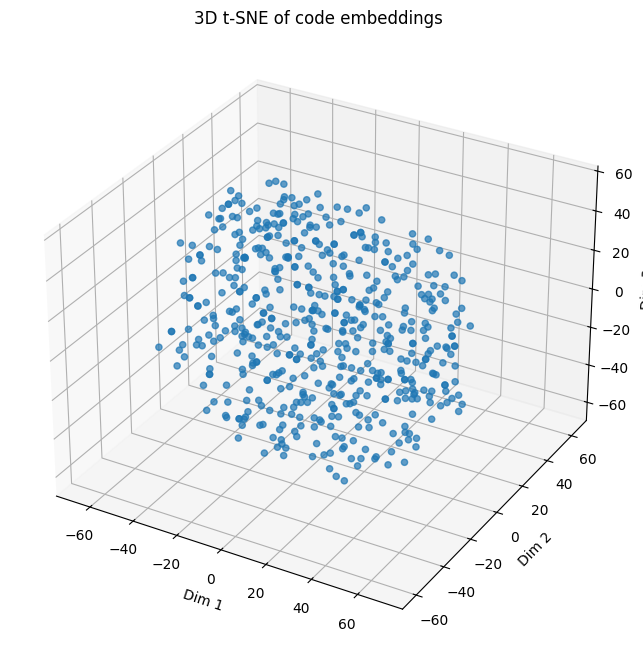

In [15]:
# 3) t-SNE → 3D
perplexity = min(30, max(2, len(texts) - 1))

tsne = TSNE(
    n_components=3,
    perplexity=perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto",
)

X = np.array(embeddings.embed_documents(texts))
X_3d = tsne.fit_transform(X)

# 4) Plot (matplotlib 3D)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_3d[:, 0],
    X_3d[:, 1],
    X_3d[:, 2],
    s=20,
    alpha=0.7
)

ax.set_title("3D t-SNE of code embeddings")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")

plt.show()

In [16]:
# receber o input do usuário
# embedar input
# cosine similarity entre input e vetores armazenados
# na llm, fazer context engineering para gerar resposta
# printar vulnerabilidade mais similar ao input do usuário com recomendações de fixes

user_input = """
import sqlite3
from typing import List, Tuple

def get_user_by_email(email: str) -> List[Tuple]:
    conn = sqlite3.connect("users.db")
    cursor = conn.cursor()

    query = "SELECT id, name, email FROM users WHERE email = ?"

    cursor.execute(query, (email,))
    results = cursor.fetchall()

    conn.close()
    return results


if __name__ == "__main__":
    user_input = "alice@example.com"
    users = get_user_by_email(user_input)

    for user in users:
        print(user)
"""
vector = embeddings.embed_query(user_input)

In [17]:
results = vectorstore.similarity_search(user_input, k=3)

for r in results:
    print(r.metadata)

{'vulnerability': 'SQL Injection', 'language': 'Python', 'id': 1}
{'id': 101, 'vulnerability': 'SQL Injection', 'language': 'Python'}
{'id': 1, 'language': 'Python', 'vulnerability': 'SQL Injection'}


In [21]:
SYSTEM_PROMPT_TEMPLATE = """
You are a knowledgeable software engineer and security expert. You are chatting with a user about software vulnerabilities. If relevant, use the given context to answer any question. If you don't know the answer, say so, the output should be in the same format as the sast scan.
User code:
{user_code}
Context:
{context}
"""

In [19]:
def answer_question():
    context = "\n\n".join(
        v for r in results
        if (v := r.metadata.get("vulnerability")) is not None
    )
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_code=user_input,context=context)
    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_input),
    ])
    return response.content

In [22]:
display(Markdown(answer_question()))

## Code Security Analysis

### ✅ **This Code is SECURE**

The provided code correctly implements **parameterized queries** (also called prepared statements), which is the proper way to prevent SQL injection attacks.

### 🔍 **Why This is Safe:**

```python
query = "SELECT id, name, email FROM users WHERE email = ?"
cursor.execute(query, (email,))
```

- The `?` placeholder is a parameterized query marker
- User input is passed as a tuple `(email,)` separately from the query string
- SQLite treats the input as a literal value, not executable SQL code

### ⚠️ **What Would Be Vulnerable:**

```python
# ❌ VULNERABLE - String concatenation
query = f"SELECT * FROM users WHERE email = '{email}'"
cursor.execute(query)
```

### 🛡️ **Best Practices Already Implemented:**

1. ✅ Parameterized queries with `?` placeholders
2. ✅ User input passed as tuple parameter
3. ✅ No string concatenation with user input
4. ✅ Proper connection handling with `conn.close()`

### 📋 **SQL Injection Prevention Checklist:**

| Practice | Status |
|----------|--------|
| Use parameterized queries | ✅ Implemented |
| Never concatenate user input | ✅ Not done |
| Use ORM frameworks | ⚠️ Not used (but not required) |
| Validate input | ⚠️ Could add additional validation |

### 🎯 **Conclusion:**

This code is **not vulnerable** to SQL injection. The context mentioning "SQL Injection" is likely a general topic reference, not an indication that this specific code has a vulnerability. The implementation follows secure coding standards for database queries.

In [12]:

import json

# Method 1: Using open() (most common)
with open("result/Semgrep-v1.0-results.json", "r") as f:
    data = json.load(f)

print(type(data))  # <class 'dict'>
print(len(data["results"]))        # Dictionary content

<class 'dict'>
2410
